In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Check if GPU is available 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
device

device(type='cuda', index=0)

#### Data

In [3]:
# Load FashionMNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=1024, num_workers=10, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1024, num_workers=10, shuffle=False)

100%|██████████| 26.4M/26.4M [00:06<00:00, 4.25MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 155kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.26MB/s]


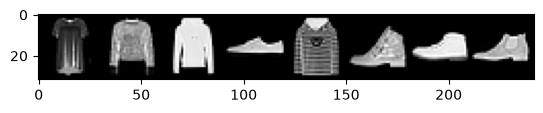

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Function to display the images
def imshow(img):
    #img = img / 255.0
    np_img = img.numpy()
    plt.imshow(np.transpose(np_img, (1, 2, 0)))
    plt.show()

for i, (images, labels) in enumerate(trainloader, 0):
    # Plot some images
    imshow(torchvision.utils.make_grid(images[:8]))  # Display 8 images from the batch
    break

#### Model

In [5]:
model = nn.Sequential(
    nn.Flatten(), nn.Linear(784, 10)
)
model = model.to(device) # Move the model to GPU if CUDA available
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


In [6]:
# Generating a random tensor
input_tensor = torch.rand(5, 28, 28).to(device) # Move data to GPU

# Feeding the tensor into the model
output = model(input_tensor)
print(output.shape)

torch.Size([5, 10])


#### Loss, Optimizer, and Evaluation Function

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# Function to compute loss and accuracy for test set
def evaluate(model, testloader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            _, argmax_indices = torch.max(outputs.data, dim=1) # returns (value, index)
            total += labels.size(0)
            correct += (argmax_indices == labels).sum().item()

    accuracy = 100 * correct / total
    test_loss = test_loss / len(testloader)
    return test_loss, accuracy

In [9]:
test_loss, test_accuracy = evaluate(model, testloader, criterion)
print(f'test_loss: {test_loss}')
print(f'test_accuracy: {test_accuracy}')

test_loss: 2.301487755775452
test_accuracy: 11.61


#### Train

In [10]:
# some parameter
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
max_epoch = 100

In [11]:
import time

In [12]:
# train
start_time = time.time()
for epoch in range(max_epoch):
    model.train()

    running_loss = 0.0
    running_correct = 0   # to track number of correct predictions
    total = 0             # to track total number of samples

    for i, (inputs, labels) in enumerate(trainloader, 0):
        # Move inputs and labels to the device
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() # .item() return the loss value in the object

        # Determine class predictions and track accuracy
        _, argmax_indices = torch.max(outputs.data, 1)
        total += labels.size(0)
        running_correct += (argmax_indices == labels).sum().item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()        

    epoch_accuracy = 100 * running_correct / total
    epoch_loss = running_loss / (i + 1)
    test_loss, test_accuracy = evaluate(model, testloader, criterion)
    print(f"Epoch [{epoch + 1}/{max_epoch}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")
    
    # save for plot
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

end_time = time.time()
train_time_sec = end_time - start_time
print(f"\nTrainning time: {train_time_sec / 60}m")

Epoch [1/100], Loss: 1.8556, Accuracy: 50.59%, Test Loss: 1.5479, Test Accuracy: 63.38%
Epoch [2/100], Loss: 1.3821, Accuracy: 65.70%, Test Loss: 1.2614, Test Accuracy: 65.33%
Epoch [3/100], Loss: 1.1740, Accuracy: 66.97%, Test Loss: 1.1153, Test Accuracy: 66.90%
Epoch [4/100], Loss: 1.0583, Accuracy: 68.36%, Test Loss: 1.0265, Test Accuracy: 68.03%
Epoch [5/100], Loss: 0.9837, Accuracy: 69.67%, Test Loss: 0.9659, Test Accuracy: 69.05%
Epoch [6/100], Loss: 0.9299, Accuracy: 70.94%, Test Loss: 0.9212, Test Accuracy: 70.14%
Epoch [7/100], Loss: 0.8902, Accuracy: 72.15%, Test Loss: 0.8865, Test Accuracy: 71.30%
Epoch [8/100], Loss: 0.8580, Accuracy: 73.05%, Test Loss: 0.8583, Test Accuracy: 72.15%
Epoch [9/100], Loss: 0.8322, Accuracy: 73.94%, Test Loss: 0.8351, Test Accuracy: 72.76%
Epoch [10/100], Loss: 0.8100, Accuracy: 74.79%, Test Loss: 0.8150, Test Accuracy: 73.47%
Epoch [11/100], Loss: 0.7912, Accuracy: 75.25%, Test Loss: 0.7980, Test Accuracy: 74.17%
Epoch [12/100], Loss: 0.7746, 

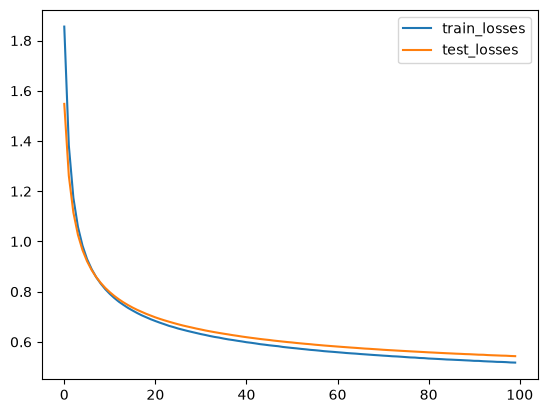

In [13]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train_losses')
plt.plot(test_losses, label='test_losses')
plt.legend()

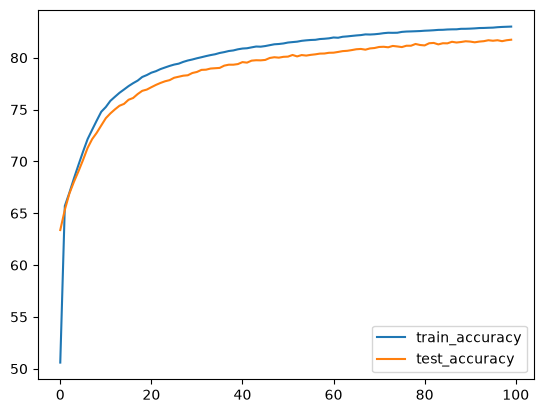

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_accuracies, label='train_accuracy')
plt.plot(test_accuracies, label='test_accuracy')
plt.legend()

### Eval (After training)

In [15]:
test_loss, test_accuracy = evaluate(model, testloader, criterion)
print(f'test_loss: {test_loss}')
print(f'test_accuracy: {test_accuracy}')

test_loss: 0.5432497739791871
test_accuracy: 81.74
